# Braindecode EEG Testing Notebook

## 1. Import Libraries

In [1]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt
import os

import braindecode
from braindecode.models import EEGNet, ShallowFBCSPNet, Deep4Net, EEGConformer
from braindecode.preprocessing import exponential_moving_standardize
from braindecode.util import set_random_seeds

import torch

print(f"Braindecode version: {braindecode.__version__}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Braindecode version: 1.2.0
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Define Helper Function to Load .mat Files

In [2]:
def load_bci_mat_file(filepath):
    mat_data = scipy.io.loadmat(filepath)
    data_struct = mat_data['data'][0]
    
    all_X, all_y, all_trials, session_info = [], [], [], []
    
    for session_idx, session in enumerate(data_struct):
        session_data = session[0][0]
        X = session_data['X']  # EEG data (samples x channels)
        fs = session_data['fs'].item() if session_data['fs'].ndim == 0 else session_data['fs'][0, 0]
        classes = session_data['classes']
        trial_field = session_data['trial']
        y_field = session_data['y']
        
        if trial_field.size > 0:
            all_X.append(X)
            all_y.append(y_field.flatten())
            all_trials.append(trial_field.flatten())
            session_info.append({
                'session_idx': session_idx,
                'fs': fs,
                'classes': [str(c.item()) for c in classes.flatten()],
                'n_trials': len(y_field.flatten())
            })
    
    return {
        'X': all_X,
        'y': np.concatenate(all_y) if all_y else np.array([]),
        'trials': np.concatenate(all_trials) if all_trials else np.array([]),
        'session_info': session_info,
        'fs': session_info[0]['fs'] if session_info else 250,
        'classes': session_info[0]['classes'] if session_info else []
    }

## 3. Load and Explore EEG Data

In [3]:
data_path = 'data/s1/A01E.mat'
eeg_data = load_bci_mat_file(data_path)

print("=" * 50)
print("EEG Data Summary")
print("=" * 50)
print(f"Number of sessions with trials: {len(eeg_data['session_info'])}")

for info in eeg_data['session_info']:
    print(f"Session {info['session_idx']}: fs={info['fs']}Hz, trials={info['n_trials']}, classes={info['classes']}")

# Concatenate all EEG data
X_all = np.concatenate(eeg_data['X'], axis=0)
y_all = eeg_data['y']

print(f"\nCombined EEG Data Shape: {X_all.shape}")
print(f"Data range: [{X_all.min():.4f}, {X_all.max():.4f}]")
print(f"Label distribution: {np.bincount(y_all)}")

EEG Data Summary
Number of sessions with trials: 6
Session 3: fs=250Hz, trials=48, classes=['left hand', 'right hand', 'feet', 'tongue']
Session 4: fs=250Hz, trials=48, classes=['left hand', 'right hand', 'feet', 'tongue']
Session 5: fs=250Hz, trials=48, classes=['left hand', 'right hand', 'feet', 'tongue']
Session 6: fs=250Hz, trials=48, classes=['left hand', 'right hand', 'feet', 'tongue']
Session 7: fs=250Hz, trials=48, classes=['left hand', 'right hand', 'feet', 'tongue']
Session 8: fs=250Hz, trials=48, classes=['left hand', 'right hand', 'feet', 'tongue']

Combined EEG Data Shape: (580410, 25)
Data range: [-929.1992, 346.6797]
Label distribution: [ 0 72 72 72 72]


## 4. Visualize Raw EEG Data

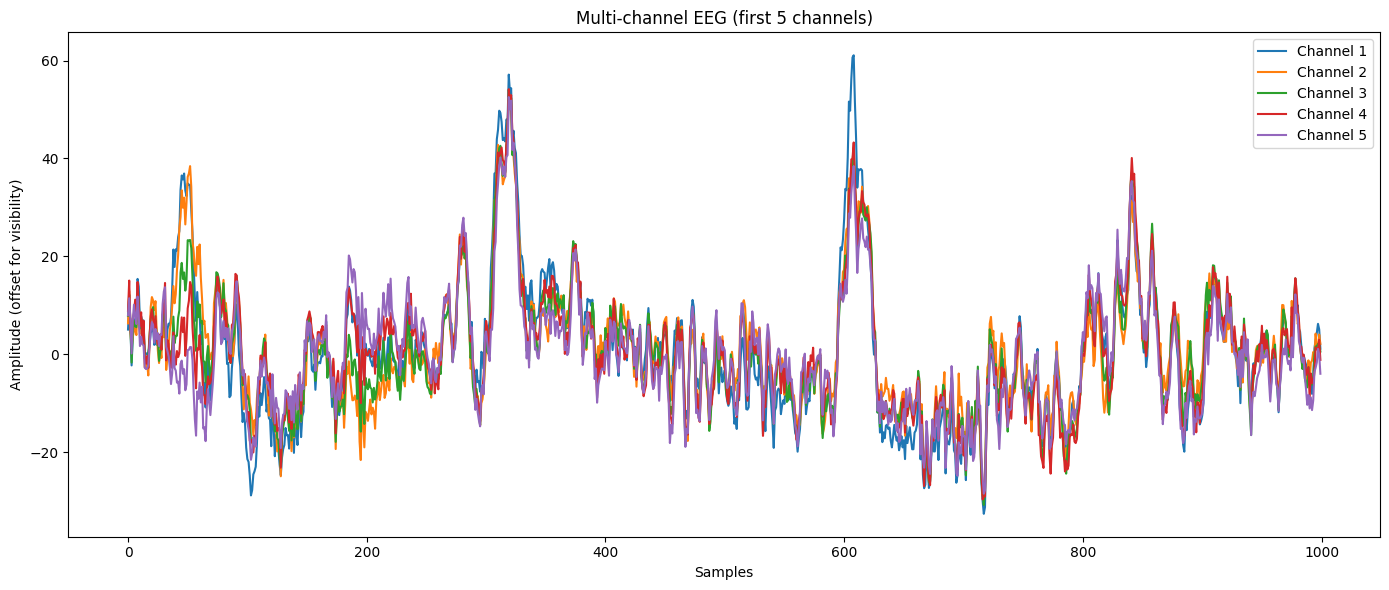

In [4]:
# Plot first few channels
X_sample = eeg_data['X'][0]
n_channels = min(5, X_sample.shape[1])

plt.figure(figsize=(14, 6))
for i in range(n_channels):
    plt.plot(X_sample[:1000, i] + i * 0.001, label=f'Channel {i+1}')
plt.title(f'Multi-channel EEG (first {n_channels} channels)')
plt.xlabel('Samples')
plt.ylabel('Amplitude (offset for visibility)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Test Braindecode Models

In [5]:
set_random_seeds(seed=42, cuda=False)

n_chans = X_sample.shape[1]  # 25 channels
n_outputs = len(np.unique(y_all))  # 4 classes
n_times = 1125  # 4.5 seconds at 250 Hz
sfreq = eeg_data['fs']  # 250 Hz

print("Model Parameters:")
print(f"  Channels: {n_chans}")
print(f"  Outputs: {n_outputs}")
print(f"  Time samples: {n_times}")
print(f"  Sampling freq: {sfreq} Hz")

X_tensor = torch.randn(4, n_chans, n_times)

Model Parameters:
  Channels: 25
  Outputs: 4
  Time samples: 1125
  Sampling freq: 250 Hz


In [6]:
# Test EEGNet
print("=" * 50)
print("Testing EEGNet Model")
print("=" * 50)
eegnet = EEGNet(n_chans=n_chans, n_outputs=n_outputs, n_times=n_times, sfreq=sfreq)
output = eegnet(X_tensor)
print(f"Input shape: {X_tensor.shape}")
print(f"Output shape: {output.shape}")
print(f"Parameters: {sum(p.numel() for p in eegnet.parameters()):,}")

Testing EEGNet Model
Input shape: torch.Size([4, 25, 1125])
Output shape: torch.Size([4, 4])
Parameters: 3,748


In [7]:
# Test ShallowFBCSPNet
print("=" * 50)
print("Testing ShallowFBCSPNet Model")
print("=" * 50)
shallow_net = ShallowFBCSPNet(n_chans=n_chans, n_outputs=n_outputs, n_times=n_times, sfreq=sfreq, final_conv_length='auto')
output = shallow_net(X_tensor)
print(f"Input shape: {X_tensor.shape}")
print(f"Output shape: {output.shape}")
print(f"Parameters: {sum(p.numel() for p in shallow_net.parameters()):,}")

Testing ShallowFBCSPNet Model
Input shape: torch.Size([4, 25, 1125])
Output shape: torch.Size([4, 4])
Parameters: 52,164


In [8]:
# Test Deep4Net
print("=" * 50)
print("Testing Deep4Net Model")
print("=" * 50)
deep4_net = Deep4Net(n_chans=n_chans, n_outputs=n_outputs, n_times=n_times, sfreq=sfreq, final_conv_length='auto')
output = deep4_net(X_tensor)
print(f"Input shape: {X_tensor.shape}")
print(f"Output shape: {output.shape}")
print(f"Parameters: {sum(p.numel() for p in deep4_net.parameters()):,}")

Testing Deep4Net Model
Input shape: torch.Size([4, 25, 1125])
Output shape: torch.Size([4, 4])
Parameters: 286,354


In [9]:
# Test EEGConformer
print("=" * 50)
print("Testing EEGConformer Model")
print("=" * 50)
conformer = EEGConformer(n_outputs=n_outputs, n_chans=n_chans, n_times=n_times, sfreq=sfreq)
output = conformer(X_tensor)
print(f"Input shape: {X_tensor.shape}")
print(f"Output shape: {output.shape}")
print(f"Parameters: {sum(p.numel() for p in conformer.parameters()):,}")

Testing EEGConformer Model
Input shape: torch.Size([4, 25, 1125])
Output shape: torch.Size([4, 4])
Parameters: 876,292


## 6. Model Comparison 

In [10]:
models = {'EEGNet': eegnet, 'ShallowFBCSPNet': shallow_net, 'Deep4Net': deep4_net, 'EEGConformer': conformer}

print("\n" + "=" * 60)
print("Model Comparison Summary")
print("=" * 60)
for name, model in models.items():
    n_params = sum(p.numel() for p in model.parameters())
    with torch.no_grad():
        out = model(X_tensor)
    print(f"{name:<20} {n_params:>15,} params, output: {tuple(out.shape)}")


Model Comparison Summary
EEGNet                         3,748 params, output: (4, 4)
ShallowFBCSPNet               52,164 params, output: (4, 4)
Deep4Net                     286,354 params, output: (4, 4)
EEGConformer                 876,292 params, output: (4, 4)


## 7. Test Data Augmentation

In [11]:
from braindecode.augmentation import TimeReverse, SignFlip, GaussianNoise, Compose

augmentations = Compose([
    TimeReverse(probability=0.5),
    SignFlip(probability=0.5),
    GaussianNoise(probability=0.5, std=0.1)
])

X_aug = torch.randn(4, n_chans, n_times)
y_aug = torch.randint(0, n_outputs, (4,))
X_aug_out, y_aug_out = augmentations(X_aug, y_aug)  # Must pass both X and y

print(f"Original X shape: {X_aug.shape}")
print(f"Augmented X shape: {X_aug_out.shape}")

Original X shape: torch.Size([4, 25, 1125])
Augmented X shape: torch.Size([4, 25, 1125])


## 8. Test Preprocessing

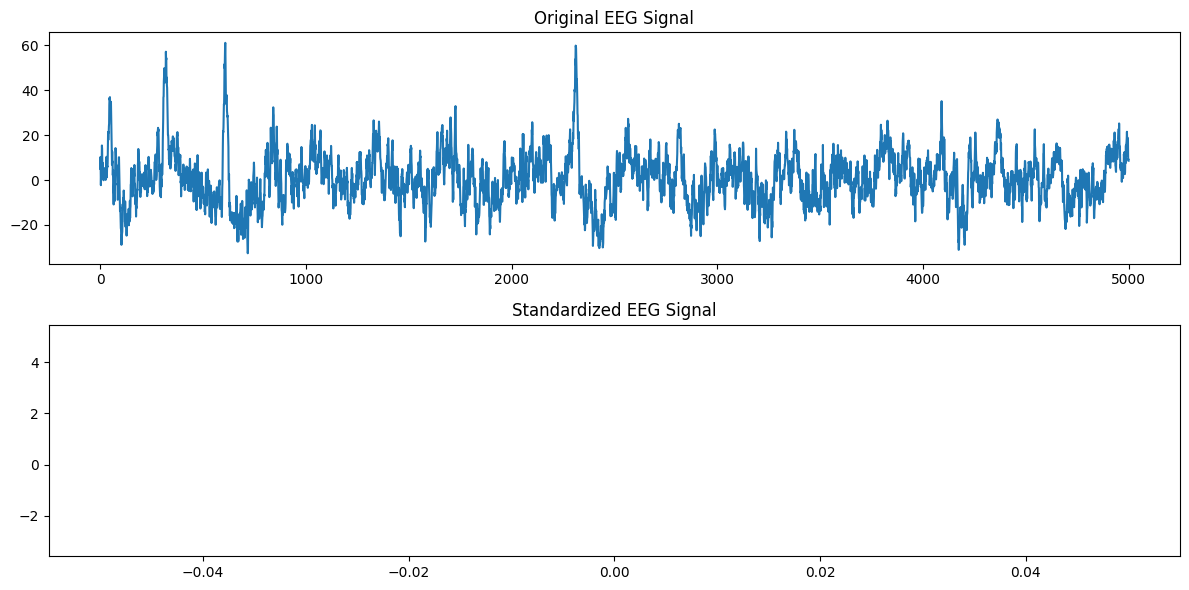

Original - Mean: 0.7466, Std: 11.3672
Standardized - Mean: -0.0007, Std: 0.9500


In [12]:
sample_data = X_sample[:5000, 0]
standardized = exponential_moving_standardize(sample_data)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].plot(sample_data)
axes[0].set_title('Original EEG Signal')
axes[1].plot(standardized)
axes[1].set_title('Standardized EEG Signal')
plt.tight_layout()
plt.show()

print(f"Original - Mean: {sample_data.mean():.4f}, Std: {sample_data.std():.4f}")
print(f"Standardized - Mean: {standardized.mean():.4f}, Std: {standardized.std():.4f}")

## 9. Load All Subjects

In [13]:
data_dir = 'data'
subjects = sorted([d for d in os.listdir(data_dir) if d.startswith('s')])

print("Available subjects:")
for subj in subjects:
    files = os.listdir(os.path.join(data_dir, subj))
    print(f"  {subj}: {files}")

Available subjects:
  s1: ['A01E.mat', 'A01T.mat']
  s2: ['A02T.mat', 'A02E.mat']
  s3: ['A03T.mat', 'A03E.mat']
  s4: ['A04T.mat', 'A04E.mat']
  s5: ['A05T.mat', 'A05E.mat']
  s6: ['A06T.mat', 'A06E.mat']
  s7: ['A07E.mat', 'A07T.mat']
  s8: ['A08E.mat', 'A08T.mat']
  s9: ['A09T.mat', 'A09E.mat']


In [14]:
all_subjects_data = {}

for subj in subjects:
    subj_path = os.path.join(data_dir, subj)
    for f in os.listdir(subj_path):
        if f.endswith('E.mat'):
            file_path = os.path.join(subj_path, f)
            data = load_bci_mat_file(file_path)
            if len(data['session_info']) > 0:
                all_subjects_data[f] = data
                print(f"Loaded {f}: {len(data['y'])} trials")

print(f"\nTotal files loaded: {len(all_subjects_data)}")

Loaded A01E.mat: 288 trials
Loaded A02E.mat: 288 trials
Loaded A03E.mat: 288 trials
Loaded A04E.mat: 288 trials
Loaded A05E.mat: 288 trials
Loaded A06E.mat: 288 trials
Loaded A07E.mat: 288 trials
Loaded A08E.mat: 288 trials
Loaded A09E.mat: 288 trials

Total files loaded: 9


## 10. Extract Trial Windows for Testing

In [15]:
def extract_trial_windows(eeg_data, window_samples=1125):
    all_windows = []
    all_labels = []
    
    trial_idx = 0
    for session_idx, X_session in enumerate(eeg_data['X']):
        n_session_trials = eeg_data['session_info'][session_idx]['n_trials']
        trial_starts = eeg_data['trials'][trial_idx:trial_idx + n_session_trials]
        labels = eeg_data['y'][trial_idx:trial_idx + n_session_trials]
        
        for i, start in enumerate(trial_starts):
            end = min(start + window_samples, X_session.shape[0])
            if end - start >= window_samples:
                # Extract window and transpose to (channels, time)
                window = X_session[start:start + window_samples, :].T
                all_windows.append(window)
                all_labels.append(labels[i] - 1)  # Convert 1-4 to 0-3
        
        trial_idx += n_session_trials
    
    return np.array(all_windows), np.array(all_labels)

# Extract trial windows from subject 1
X_trials, y_trials = extract_trial_windows(eeg_data, window_samples=1125)
print(f"Extracted {len(X_trials)} trials")
print(f"X_trials shape: {X_trials.shape}")
print(f"y_trials shape: {y_trials.shape}")
print(f"Label distribution: {np.bincount(y_trials + 1)}")

Extracted 288 trials
X_trials shape: (288, 25, 1125)
y_trials shape: (288,)
Label distribution: [ 0 72 72 72 72]


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch.nn.functional as F

# Split data into train and test sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_trials, y_trials, test_size=0.3, random_state=42, stratify=y_trials
)

X_train_tensor = torch.FloatTensor(X_train)
X_test_tensor = torch.FloatTensor(X_test)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

print(f"Training set: {X_train_tensor.shape}, {y_train_tensor.shape}")
print(f"Test set: {X_test_tensor.shape}, {y_test_tensor.shape}")
print(f"Train label distribution: {np.bincount(y_train + 1)}")
print(f"Test label distribution: {np.bincount(y_test + 1)}")

Training set: torch.Size([201, 25, 1125]), torch.Size([201])
Test set: torch.Size([87, 25, 1125]), torch.Size([87])
Train label distribution: [ 0 50 51 50 50]
Test label distribution: [ 0 22 21 22 22]


In [17]:
def train_and_predict(model, X_train, y_train, X_test, y_test, epochs=50, lr=0.001, batch_size=32):
    # Loss and optimizer
    criterion = torch.nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    # Training loop
    losses = []
    accuracies = []
    
    model.train()
    for epoch in range(epochs):
        # Shuffle data
        perm = torch.randperm(len(X_train))
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]
        
        epoch_loss = 0.0
        correct = 0
        total = 0
        
        # Mini-batch training
        for i in range(0, len(X_train), batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            
            # Forward pass
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            
            # Backward pass
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += y_batch.size(0)
            correct += (predicted == y_batch).sum().item()
        
        scheduler.step()
        avg_loss = epoch_loss / (len(X_train) // batch_size)
        acc = correct / total
        losses.append(avg_loss)
        accuracies.append(acc)
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Train Acc: {acc:.4f}")
    
    # Get predictions on test set
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test)
        test_probs = F.softmax(test_outputs, dim=1)
        _, test_predicted = torch.max(test_outputs, 1)
    
    return test_predicted.numpy(), test_probs.numpy(), losses, accuracies

print("Training function ready!")

Training function ready!


In [25]:
NEPOCHS=100

In [32]:
# Train and test EEGNet
print("=" * 60)
print("Training EEGNet Model")
print("=" * 60)

eegnet_model = EEGNet(n_chans=n_chans, n_outputs=n_outputs, n_times=n_times, sfreq=sfreq)
y_pred_eegnet, y_probs_eegnet, losses_eegnet, accs_eegnet = train_and_predict(
    eegnet_model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=300
)

print(f"\nEEGNet Test Accuracy: {accuracy_score(y_test, y_pred_eegnet):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_eegnet, target_names=['Left Hand', 'Right Hand', 'Feet', 'Tongue'])}")

Training EEGNet Model
Epoch 10/300, Loss: 1.0321, Train Acc: 0.7264
Epoch 20/300, Loss: 0.6463, Train Acc: 0.8657
Epoch 30/300, Loss: 0.4080, Train Acc: 0.9204
Epoch 40/300, Loss: 0.2665, Train Acc: 0.9652
Epoch 50/300, Loss: 0.2217, Train Acc: 0.9751
Epoch 60/300, Loss: 0.1303, Train Acc: 0.9900
Epoch 70/300, Loss: 0.1368, Train Acc: 0.9801
Epoch 80/300, Loss: 0.1104, Train Acc: 0.9950
Epoch 90/300, Loss: 0.1046, Train Acc: 0.9950
Epoch 100/300, Loss: 0.0977, Train Acc: 0.9900
Epoch 110/300, Loss: 0.0717, Train Acc: 1.0000
Epoch 120/300, Loss: 0.0886, Train Acc: 0.9900
Epoch 130/300, Loss: 0.0741, Train Acc: 0.9851
Epoch 140/300, Loss: 0.0600, Train Acc: 1.0000
Epoch 150/300, Loss: 0.0696, Train Acc: 0.9900
Epoch 160/300, Loss: 0.0592, Train Acc: 0.9950
Epoch 170/300, Loss: 0.0533, Train Acc: 1.0000
Epoch 180/300, Loss: 0.0532, Train Acc: 1.0000
Epoch 190/300, Loss: 0.0607, Train Acc: 0.9950
Epoch 200/300, Loss: 0.0561, Train Acc: 1.0000
Epoch 210/300, Loss: 0.0513, Train Acc: 1.0000


In [33]:
# Train and test Deep4Net
print("=" * 60)
print("Training Deep4Net Model")
print("=" * 60)

deep4_model = Deep4Net(n_chans=n_chans, n_outputs=n_outputs, n_times=n_times, sfreq=sfreq, final_conv_length='auto')
y_pred_deep4, y_probs_deep4, losses_deep4, accs_deep4 = train_and_predict(
    deep4_model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=150
)

print(f"\nDeep4Net Test Accuracy: {accuracy_score(y_test, y_pred_deep4):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_deep4, target_names=['Left Hand', 'Right Hand', 'Feet', 'Tongue'])}")

Training Deep4Net Model
Epoch 10/150, Loss: 1.5117, Train Acc: 0.4478
Epoch 20/150, Loss: 0.9433, Train Acc: 0.6567
Epoch 30/150, Loss: 0.5477, Train Acc: 0.8657
Epoch 40/150, Loss: 0.2882, Train Acc: 0.9303
Epoch 50/150, Loss: 0.2363, Train Acc: 0.9254
Epoch 60/150, Loss: 0.1831, Train Acc: 0.9652
Epoch 70/150, Loss: 0.1507, Train Acc: 0.9701
Epoch 80/150, Loss: 0.0985, Train Acc: 0.9900
Epoch 90/150, Loss: 0.1053, Train Acc: 0.9950
Epoch 100/150, Loss: 0.0705, Train Acc: 0.9900
Epoch 110/150, Loss: 0.0616, Train Acc: 1.0000
Epoch 120/150, Loss: 0.0640, Train Acc: 0.9950
Epoch 130/150, Loss: 0.0644, Train Acc: 1.0000
Epoch 140/150, Loss: 0.0551, Train Acc: 1.0000
Epoch 150/150, Loss: 0.0675, Train Acc: 0.9950

Deep4Net Test Accuracy: 0.5747
Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.52      0.73      0.60        22
  Right Hand       0.60      0.71      0.65        21
        Feet       0.56      0.45      0.50        22
      To

In [34]:
# Train and test ShallowFBCSPNet
print("=" * 60)
print("Training ShallowFBCSPNet Model")
print("=" * 60)

shallow_model = ShallowFBCSPNet(n_chans=n_chans, n_outputs=n_outputs, n_times=n_times, sfreq=sfreq, final_conv_length='auto')
y_pred_shallow, y_probs_shallow, losses_shallow, accs_shallow = train_and_predict(
    shallow_model, X_train_tensor, y_train_tensor, X_test_tensor, y_test_tensor, epochs=150
)

print(f"\nShallowFBCSPNet Test Accuracy: {accuracy_score(y_test, y_pred_shallow):.4f}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_shallow, target_names=['Left Hand', 'Right Hand', 'Feet', 'Tongue'])}")

Training ShallowFBCSPNet Model
Epoch 10/150, Loss: 0.5520, Train Acc: 0.8209
Epoch 20/150, Loss: 0.1868, Train Acc: 0.9502
Epoch 30/150, Loss: 0.1138, Train Acc: 0.9900
Epoch 40/150, Loss: 0.0449, Train Acc: 1.0000
Epoch 50/150, Loss: 0.0322, Train Acc: 1.0000
Epoch 60/150, Loss: 0.0237, Train Acc: 1.0000
Epoch 70/150, Loss: 0.0291, Train Acc: 1.0000
Epoch 80/150, Loss: 0.0271, Train Acc: 1.0000
Epoch 90/150, Loss: 0.0255, Train Acc: 1.0000
Epoch 100/150, Loss: 0.0204, Train Acc: 1.0000
Epoch 110/150, Loss: 0.0130, Train Acc: 1.0000
Epoch 120/150, Loss: 0.0089, Train Acc: 1.0000
Epoch 130/150, Loss: 0.0162, Train Acc: 1.0000
Epoch 140/150, Loss: 0.0137, Train Acc: 1.0000
Epoch 150/150, Loss: 0.0128, Train Acc: 1.0000

ShallowFBCSPNet Test Accuracy: 0.6667
Classification Report:
              precision    recall  f1-score   support

   Left Hand       0.70      0.64      0.67        22
  Right Hand       0.66      0.90      0.76        21
        Feet       0.60      0.55      0.57     

## 13. Compare Model Predictions and Results

In [35]:
class_names = ['Left Hand', 'Right Hand', 'Feet', 'Tongue']

results = {
    'EEGNet': {'preds': y_pred_eegnet, 'probs': y_probs_eegnet, 'losses': losses_eegnet, 'accs': accs_eegnet},
    'ShallowFBCSPNet': {'preds': y_pred_shallow, 'probs': y_probs_shallow, 'losses': losses_shallow, 'accs': accs_shallow},
    'Deep4Net': {'preds': y_pred_deep4, 'probs': y_probs_deep4, 'losses': losses_deep4, 'accs': accs_deep4}
}

print("=" * 70)
print("MODEL COMPARISON ON TEST DATA")
print("=" * 70)
print(f"{'Model':<20} {'Test Accuracy':>15} {'vs Random (25%)':>15}")
print("-" * 70)

for name, res in results.items():
    acc = accuracy_score(y_test, res['preds'])
    improvement = (acc - 0.25) / 0.25 * 100
    print(f"{name:<20} {acc:>15.2%} {improvement:>14.1f}%")

print("-" * 70)

MODEL COMPARISON ON TEST DATA
Model                  Test Accuracy vs Random (25%)
----------------------------------------------------------------------
EEGNet                        72.41%          189.7%
ShallowFBCSPNet               66.67%          166.7%
Deep4Net                      57.47%          129.9%
----------------------------------------------------------------------
Random baseline accuracy: 25.0%


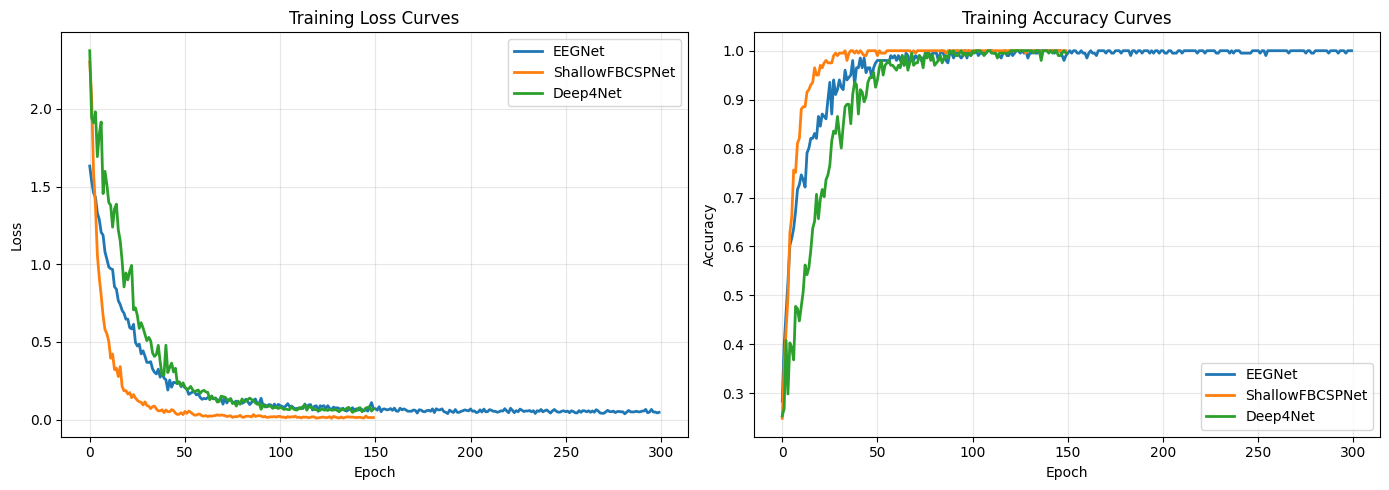

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    axes[0].plot(res['losses'], label=name, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curves')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for name, res in results.items():
    axes[1].plot(res['accs'], label=name, linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy Curves')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

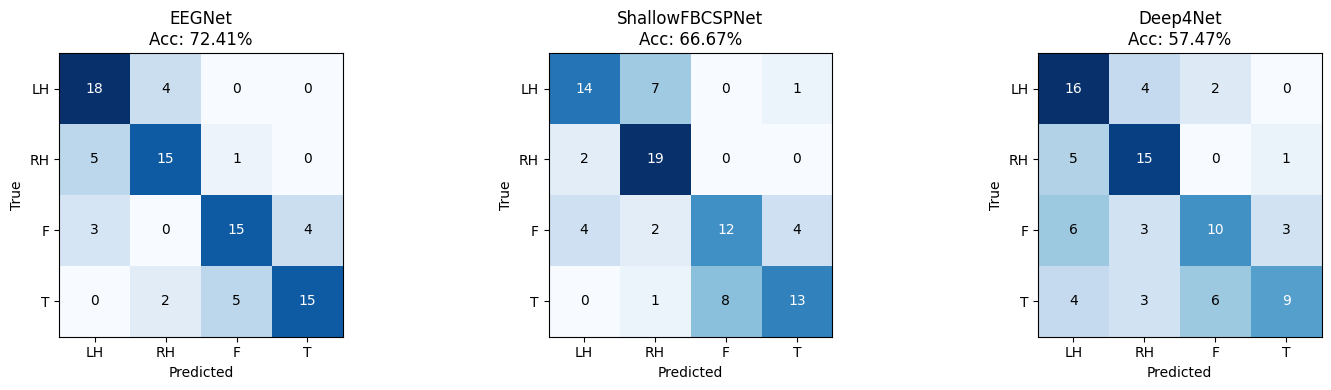

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['preds'])
    im = axes[idx].imshow(cm, interpolation='nearest', cmap='Blues')
    axes[idx].set_title(f'{name}\nAcc: {accuracy_score(y_test, res["preds"]):.2%}')
    axes[idx].set_xticks(range(4))
    axes[idx].set_yticks(range(4))
    axes[idx].set_xticklabels(['LH', 'RH', 'F', 'T'], fontsize=10)
    axes[idx].set_yticklabels(['LH', 'RH', 'F', 'T'], fontsize=10)
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    
    for i in range(4):
        for j in range(4):
            axes[idx].text(j, i, cm[i, j], ha='center', va='center',
                          color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.tight_layout()
plt.show()